In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm,skew
from scipy import stats
import datetime as dt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from itertools import combinations
%matplotlib inline

In [8]:
!pip list

Package                           Version
--------------------------------- ------------------
absl-py                           2.3.1
aext-assistant                    4.0.15
aext-assistant-server             4.0.15
aext-core                         4.0.15
aext-core-server                  4.0.15
aext-panels                       4.0.15
aext-panels-server                4.0.15
aext-share-notebook               4.0.15
aext-share-notebook-server        4.0.15
aext-shared                       4.0.15
agate                             1.9.1
aiobotocore                       2.12.3
aiohttp                           3.9.5
aioitertools                      0.7.1
aiosignal                         1.2.0
alabaster                         0.7.16
altair                            5.0.1
anaconda-anon-usage               0.4.4
anaconda-catalogs                 0.2.0
anaconda-client                   1.12.3
anaconda-cloud-auth               0.5.1
anaconda-navigator                2.6.0
anaconda-proj

In [9]:
new = pd.read_csv('new_merchant_transactions.csv')
historical = pd.read_csv('historical_transactions.csv')
merchants = pd.read_csv('merchants.csv')

In [10]:
historical.head()

,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id
0,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-8,-0.703331,2017-06-25 15:33:07,1.0,16,37
1,Y,C_ID_4e6213e9bc,88,N,0,A,367,M_ID_86ec983688,-7,-0.733128,2017-07-15 12:10:45,1.0,16,16
2,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_979ed661fc,-6,-0.720386,2017-08-09 22:04:29,1.0,16,37
3,Y,C_ID_4e6213e9bc,88,N,0,A,560,M_ID_e6d5ae8ea6,-5,-0.735352,2017-09-02 10:06:26,1.0,16,34
4,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-11,-0.722865,2017-03-10 01:14:19,1.0,16,37


In [11]:
historical_cleaned = historical.dropna()

In [12]:
to_year = pd.to_datetime(historical_cleaned['purchase_date'])
historical_cleaned.loc[:,'year'] = to_year.dt.year
historical_cleaned.loc[:,'date'] = to_year.dt.date

/var/folders/1v/2zr5v4ln72s0cjq21hbhbv3w0000gn/T/ipykernel_2726/749679181.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  historical_cleaned.loc[:,'year'] = to_year.dt.year
/var/folders/1v/2zr5v4ln72s0cjq21hbhbv3w0000gn/T/ipykernel_2726/749679181.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  historical_cleaned.loc[:,'date'] = to_year.dt.date


In [13]:
print(f"Earliest date:", historical_cleaned['purchase_date'].min())
print(f"Latest date:", historical_cleaned['purchase_date'].max())

Earliest date: 2017-01-01 00:00:08
Latest date: 2018-02-28 23:59:49


In [14]:
#The dataset contains the data from 2017/01/01 to 2018/02/28
#Here, I am going to use the annual data from 2017/01/01 to 2018/02/28
historical_cleaned['date'] = pd.to_datetime(historical_cleaned['date'])

start_date = pd.to_datetime('2017-01-01')
end_date = pd.to_datetime('2018-02-28')
filtered = historical_cleaned[(historical_cleaned['date']>= start_date) & (historical_cleaned['date']<= end_date)].copy()
filtered.groupby('date').agg(['count','min','max'])

/var/folders/1v/2zr5v4ln72s0cjq21hbhbv3w0000gn/T/ipykernel_2726/2247287134.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  historical_cleaned['date'] = pd.to_datetime(historical_cleaned['date'])


authorized_flag         card_id                                    \
                     count min max   count              min              max   
date                                                                           
2017-01-01           10754   N   Y   10754  C_ID_00087f3079  C_ID_fffd1207a8   
2017-01-02           29080   N   Y   29080  C_ID_00024e244b  C_ID_fffd1207a8   
2017-01-03           32080   N   Y   32080  C_ID_00087f3079  C_ID_fffd1207a8   
2017-01-04           33536   N   Y   33536  C_ID_00024e244b  C_ID_fffe78b232   
2017-01-05           35242   N   Y   35242  C_ID_00032df08f  C_ID_ffff828181   
...                    ...  ..  ..     ...              ...              ...   
2018-02-24           92856   N   Y   92856  C_ID_0001238066  C_ID_fffeed3a89   
2018-02-25           56681   N   Y   56681  C_ID_000183fdda  C_ID_fffffd5772   
2018-02-26           65817   N   Y   65817  C_ID_0003f41435  C_ID_fffea6de74   
2018-02-27           71210   N   Y   71210  C_ID_0001238066  C_ID_fffeed3a89   
2018-02-28           78251   N   Y   78251  C_ID_0005f16cc8  C_ID_fffeed3a89   

           city_id          category_1  ... category_2 state_id          \
             count min  max      count  ...        max    count min max   
date                                    ...                               
2017-01-01   10754   1  347      10754  ...        5.0    10754   1  24   
2017-01-02   29080   1  347      29080  ...        5.0    29080   1  24   
2017-01-03   32080   1  347      32080  ...        5.0    32080   1  24   
2017-01-04   33536   1  347      33536  ...        5.0    33536   1  24   
2017-01-05   35242   1  347      35242  ...        5.0    35242   1  24   
...            ...  ..  ...        ...  ...        ...      ...  ..  ..   
2018-02-24   92856   1  347      92856  ...        5.0    92856   1  24   
2018-02-25   56681   1  347      56681  ...        5.0    56681   1  24   
2018-02-26   65817   1  347      65817  ...        5.0    65817   1  24   
2018-02-27   71210   1  347      71210  ...        5.0    71210   1  24   
2018-02-28   78251   1  347      78251  ...        5.0    78251   1  24   

           subsector_id           year              
                  count min max  count   min   max  
date                                                
2017-01-01        10754   1  41  10754  2017  2017  
2017-01-02        29080   1  41  29080  2017  2017  
2017-01-03        32080   1  41  32080  2017  2017  
2017-01-04        33536   1  41  33536  2017  2017  
2017-01-05        35242   1  41  35242  2017  2017  
...                 ...  ..  ..    ...   ...   ...  
2018-02-24        92856   1  41  92856  2018  2018  
2018-02-25        56681   1  41  56681  2018  2018  
2018-02-26        65817   1  41  65817  2018  2018  
2018-02-27        71210   1  41  71210  2018  2018  
2018-02-28        78251   1  41  78251  2018  2018  

[424 rows x 45 columns]

In [15]:
filtered.head()

,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id,year,date
0,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-8,-0.703331,2017-06-25 15:33:07,1.0,16,37,2017,2017-06-25
1,Y,C_ID_4e6213e9bc,88,N,0,A,367,M_ID_86ec983688,-7,-0.733128,2017-07-15 12:10:45,1.0,16,16,2017,2017-07-15
2,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_979ed661fc,-6,-0.720386,2017-08-09 22:04:29,1.0,16,37,2017,2017-08-09
3,Y,C_ID_4e6213e9bc,88,N,0,A,560,M_ID_e6d5ae8ea6,-5,-0.735352,2017-09-02 10:06:26,1.0,16,34,2017,2017-09-02
4,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-11,-0.722865,2017-03-10 01:14:19,1.0,16,37,2017,2017-03-10


In [16]:
filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26169697 entries, 0 to 29112360
Data columns (total 16 columns):
 #   Column                Dtype         
---  ------                -----         
 0   authorized_flag       object        
 1   card_id               object        
 2   city_id               int64         
 3   category_1            object        
 4   installments          int64         
 5   category_3            object        
 6   merchant_category_id  int64         
 7   merchant_id           object        
 8   month_lag             int64         
 9   purchase_amount       float64       
 10  purchase_date         object        
 11  category_2            float64       
 12  state_id              int64         
 13  subsector_id          int64         
 14  year                  int32         
 15  date                  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int32(1), int64(6), object(6)
memory usage: 3.2+ GB


## Creating RFM variables

### Frequency

In [19]:
#Frequency dataset
Frequency_filtered = filtered.groupby('card_id').purchase_date.count().reset_index(name='frequency')
Frequency_filtered.head()

,card_id,frequency
0,C_ID_00007093c1,121
1,C_ID_0001238066,113
2,C_ID_0001506ef0,66
3,C_ID_0001793786,102
4,C_ID_000183fdda,136


### Recency

In [21]:
#Recency dataset
most_recent = filtered['date'].max()+dt.timedelta(days=1)
print(most_recent)

2018-03-01 00:00:00


In [22]:
Recency_filtered = filtered.groupby('card_id').date.agg(lambda x:(most_recent - x.max())).reset_index(name='recency')
print(Recency_filtered )

                card_id  recency
0       C_ID_00007093c1  21 days
1       C_ID_0001238066   2 days
2       C_ID_0001506ef0  12 days
3       C_ID_0001793786 125 days
4       C_ID_000183fdda   4 days
...                 ...      ...
319654  C_ID_ffff1d9928  52 days
319655  C_ID_ffff579d3a   6 days
319656  C_ID_ffff756266 154 days
319657  C_ID_ffff828181  10 days
319658  C_ID_fffffd5772   4 days

[319659 rows x 2 columns]


### Monetary Value

In [24]:
#Monetary Value dataset
#The purchase amount here is normalized
#Going to add 1 to be able to calculate the sum
filtered['purchase_amount'] = filtered['purchase_amount'] +1
Monetary_filtered = filtered.groupby('card_id').purchase_amount.sum().reset_index(name='monetary')
print(Monetary_filtered)

                card_id   monetary
0       C_ID_00007093c1  64.194000
1       C_ID_0001238066  44.172385
2       C_ID_0001506ef0  31.398121
3       C_ID_0001793786  88.780546
4       C_ID_000183fdda  65.877791
...                 ...        ...
319654  C_ID_ffff1d9928   3.162125
319655  C_ID_ffff579d3a  33.707232
319656  C_ID_ffff756266  17.637532
319657  C_ID_ffff828181  65.939938
319658  C_ID_fffffd5772  13.888041

[319659 rows x 2 columns]


In [25]:
rfm = pd.merge(Recency_filtered, Frequency_filtered, on='card_id', how='outer')
rfm = pd.merge(rfm, Monetary_filtered, on='card_id', how='outer')
rfm.head()

,card_id,recency,frequency,monetary
0,C_ID_00007093c1,21 days,121,64.194000
1,C_ID_0001238066,2 days,113,44.172385
2,C_ID_0001506ef0,12 days,66,31.398121
3,C_ID_0001793786,125 days,102,88.780546
4,C_ID_000183fdda,4 days,136,65.877791


In [26]:
rfm.describe()

,recency,frequency,monetary
count,319659,319659.000000,3.196590e+05
mean,51 days 20:42:30.572954303,81.867543,8.787796e+01
std,77 days 22:40:31.785400671,100.954132,1.072009e+04
min,1 days 00:00:00,1.000000,2.531072e-01
25%,3 days 00:00:00,22.000000,9.467774e+00
50%,15 days 00:00:00,48.000000,1.987415e+01
75%,64 days 00:00:00,101.000000,4.102331e+01
max,424 days 00:00:00,2889.000000,6.010608e+06


# Assigning RFM scores
### RFM Scoring
Each customer is assigned a 1–5 score for Recency (R), Frequency (F), and Monetary value (M) using 5 equal-width bins (pd.cut).

- Recency: **Lower** is better → 5 = most recent, 1 = least recent
- Frequency: **Higher** is better → 5 = most frequent, 1 = least frequent
- Monetary: **Higher** is better → 5 = highest spending, 1 = lowest spending

The resulting RFM score summarizes customer value and engagement, with higher scores indicating more valuable/active customers.

In [28]:
#Assign RFM scores
#
recency_scores = range(5,0,-1)
frequency_scores = range(1,6)
monetary_scores = range(1,6)

rfm['r'] = pd.cut(rfm['recency'], bins=5, labels = recency_scores)
rfm['f'] = pd.cut(rfm['frequency'], bins=5, labels = frequency_scores)
rfm['m'] = pd.cut(rfm['monetary'], bins=5, labels = monetary_scores)

In [29]:
# Create percentile ranks first, then assign RFM scores

rfm['r'] = pd.qcut(
    rfm['recency'].rank(method='first'),
    q=5,
    labels=[5, 4, 3, 2, 1]
)

rfm['f'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

rfm['m'] = pd.qcut(
    rfm['monetary'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

# Convert scores to integers
rfm[['r', 'f', 'm']] = rfm[['r', 'f', 'm']].astype(int)

In [30]:
rfm['rfm'] = (
    rfm['r'].astype(str) +
    rfm['f'].astype(str) +
    rfm['m'].astype(str)
)

rfm['rfm points'] = rfm[['r', 'f', 'm']].sum(axis=1)

In [31]:
def rfm_segment(x):
    return str(x['r'])+str(x['f'])+str(x['m'])

rfm['rfm']=rfm.apply(rfm_segment, axis=1)
rfm['rfm points']=rfm[['r','f','m']].sum(axis=1)
rfm.head()

,card_id,recency,frequency,monetary,r,f,m,rfm,rfm points
0,C_ID_00007093c1,21 days,121,64.194000,3,4,5,345,12
1,C_ID_0001238066,2 days,113,44.172385,5,4,4,544,13
2,C_ID_0001506ef0,12 days,66,31.398121,3,4,4,344,11
3,C_ID_0001793786,125 days,102,88.780546,1,4,5,145,10
4,C_ID_000183fdda,4 days,136,65.877791,4,5,5,455,14


In [32]:
rfm.groupby('r').recency.agg(['mean','min','max'])

,mean,min,max
r,,,
1,186 days 03:17:42.904335856,90 days,424 days
2,51 days 01:13:52.709754113,29 days,90 days
3,16 days 03:48:50.803522547,8 days,29 days
4,4 days 16:21:31.522242382,2 days,8 days
5,1 days 06:49:46.673340424,1 days,2 days


In [33]:
rfm.dtypes

card_id                object
recency       timedelta64[ns]
frequency               int64
monetary              float64
r                       int64
f                       int64
m                       int64
rfm                    object
rfm points              int64
dtype: object

In [34]:
rfm[['r', 'f', 'm']].describe()

,r,f,m
count,319659.000000,319659.000000,319659.000000
mean,3.000000,3.000000,3.000000
std,1.414218,1.414218,1.414218
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000
50%,3.000000,3.000000,3.000000
75%,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000


In [35]:
rfm.groupby('rfm')[['recency', 'frequency', 'monetary']].agg(
    ['min', 'max', 'mean', 'count']
)

recency                                             frequency        \
        min      max                        mean  count       min   max   
rfm                                                                       
111 90 days 424 days 199 days 01:07:12.240014286  16799         1    18   
112 90 days 422 days 182 days 11:35:15.528490648   2299         1    18   
113 90 days 419 days 175 days 05:58:16.650717704    627         1    18   
114 90 days 388 days 161 days 13:26:42.094240838    191         1    18   
115 91 days 397 days           178 days 02:33:36     75         2    18   
..      ...      ...                         ...    ...       ...   ...   
543  1 days   2 days   1 days 06:49:20.271019402   3247        64    96   
544  1 days   2 days   1 days 07:05:01.096079786  10127        64   121   
545  1 days   2 days   1 days 07:29:10.092421441   2164        64   121   
554  1 days   2 days   1 days 06:27:42.574010595   3209       121   185   
555  1 days   2 days   1 days 05:31:12.037220522  23213       121  2118   

                         monetary                                     
           mean  count        min           max          mean  count  
rfm                                                                   
111    8.373237  16799   0.253107  7.855084e+00      3.619122  16799  
112   12.098304   2299   7.856097  1.507190e+01     10.350491   2299  
113   11.845295    627  15.101684  2.601150e+01     19.189620    627  
114   11.314136    191  26.078619  4.878554e+01     33.564047    191  
115   11.120000     75  49.423095  6.010608e+06  80926.457755     75  
..          ...    ...        ...           ...           ...    ...  
543   73.419464   3247  17.188509  2.605959e+01     22.969178   3247  
544   93.411573  10127  26.061200  4.914756e+01     34.931471  10127  
545   98.429298   2164  49.155252  8.562209e+04    339.873235   2164  
554  137.995014   3209  33.080286  4.914695e+01     43.314233   3209  
555  285.799466  23213  49.148216  1.380817e+05    245.132048  23213  

[95 rows x 12 columns]

In [36]:
#The leargest to smallest segments are as follows:
rfm.groupby(['rfm']).size().sort_values(ascending=False)

rfm
555    23213
111    16799
211    14365
455    12215
311    11271
       ...  
115       75
315       62
514       44
415       24
515       10
Length: 95, dtype: int64

In [37]:
rfm.groupby(['rfm points']).size().sort_values(ascending=False)

rfm points
9     30244
7     28963
11    28614
8     27861
10    27157
6     26582
5     26317
12    24932
15    23213
13    21349
4     20040
14    17588
3     16799
dtype: int64

In [38]:
#There are 5x5x5 = 125 segments here
#We can segment them into 'Top tier', 'High tier','Mid-high tier','Mid-tier', and 'Low tier'customers 
# Segment customers based on total RFM score
tier_labels = [
    'Low tier',
    'Mid-tier',
    'Mid-high tier',
    'High tier',
    'Top tier'
]

rfm['Tier'] = pd.cut(
    rfm['rfm points'],
    bins=5,
    labels=tier_labels
)
rfm.head()

,card_id,recency,frequency,monetary,r,f,m,rfm,rfm points,Tier
0,C_ID_00007093c1,21 days,121,64.194000,3,4,5,345,12,High tier
1,C_ID_0001238066,2 days,113,44.172385,5,4,4,544,13,Top tier
2,C_ID_0001506ef0,12 days,66,31.398121,3,4,4,344,11,High tier
3,C_ID_0001793786,125 days,102,88.780546,1,4,5,145,10,Mid-high tier
4,C_ID_000183fdda,4 days,136,65.877791,4,5,5,455,14,Top tier


In [39]:
rfm_tier = rfm.groupby('Tier').size()
# Convert to dataframe
rfm_tier = rfm_tier.to_frame()
print(rfm_tier)

                   0
Tier                
Low tier       63156
Mid-tier       55545
Mid-high tier  85262
High tier      53546
Top tier       62150


/var/folders/1v/2zr5v4ln72s0cjq21hbhbv3w0000gn/T/ipykernel_2726/973477541.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rfm_tier = rfm.groupby('Tier').size()


In [40]:
# mind that the index is "Tier' here
type(rfm_tier)

pandas.core.frame.DataFrame

## Create Variables - Churn, AOV, and LTV

### Create churn
Churned customer = a customer/card whose last purchase was followed by at least 90 days with no subsequent purchase, where the dataset contains enough observation time to actually observe those 90 days.

In [43]:
# purchase date to datetime
filtered["purchase_date"] = pd.to_datetime(filtered["purchase_date"])

In [44]:
# Find each customer's last purchase
customer_summary = (
    filtered
    .groupby("card_id")
    .agg(
        first_purchase_date=("purchase_date", "min"),
        last_purchase_date=("purchase_date", "max"),
        total_orders=("purchase_date", "count"),
        total_spend=("purchase_amount", "sum")
    )
    .reset_index()
)
customer_summary.head()

,card_id,first_purchase_date,last_purchase_date,total_orders,total_spend
0,C_ID_00007093c1,2017-02-14 14:00:43,2018-02-08 16:37:19,121,64.194000
1,C_ID_0001238066,2017-09-28 22:25:14,2018-02-27 16:18:59,113,44.172385
2,C_ID_0001506ef0,2017-01-14 16:16:01,2018-02-17 12:33:56,66,31.398121
3,C_ID_0001793786,2017-01-21 10:15:21,2017-10-27 13:51:16,102,88.780546
4,C_ID_000183fdda,2017-08-07 09:49:14,2018-02-25 20:57:08,136,65.877791


In [45]:
# Define the dataset observation end date
observation_end = pd.to_datetime('2018-02-28')

# Flag churn after 90 days
customer_summary["days_since_last_purchase"] = (
    observation_end - customer_summary["last_purchase_date"]
).dt.days

customer_summary["churned_90d"] = (
    customer_summary["days_since_last_purchase"] >= 90
).astype(int)

customer_summary.head()

,card_id,first_purchase_date,last_purchase_date,total_orders,total_spend,days_since_last_purchase,churned_90d
0,C_ID_00007093c1,2017-02-14 14:00:43,2018-02-08 16:37:19,121,64.194000,19,0
1,C_ID_0001238066,2017-09-28 22:25:14,2018-02-27 16:18:59,113,44.172385,0,0
2,C_ID_0001506ef0,2017-01-14 16:16:01,2018-02-17 12:33:56,66,31.398121,10,0
3,C_ID_0001793786,2017-01-21 10:15:21,2017-10-27 13:51:16,102,88.780546,123,1
4,C_ID_000183fdda,2017-08-07 09:49:14,2018-02-25 20:57:08,136,65.877791,2,0


In [46]:
# check % churned
customer_summary.groupby('churned_90d').card_id.count()

churned_90d
0    257824
1     61835
Name: card_id, dtype: int64

### AOV
AOV = Total Spend / Number of Orders

In [48]:
customer_summary["AOV"] = (
    customer_summary["total_spend"] /
    customer_summary["total_orders"]
)
customer_summary.head()

,card_id,first_purchase_date,last_purchase_date,total_orders,total_spend,days_since_last_purchase,churned_90d,AOV
0,C_ID_00007093c1,2017-02-14 14:00:43,2018-02-08 16:37:19,121,64.194000,19,0,0.530529
1,C_ID_0001238066,2017-09-28 22:25:14,2018-02-27 16:18:59,113,44.172385,0,0,0.390906
2,C_ID_0001506ef0,2017-01-14 16:16:01,2018-02-17 12:33:56,66,31.398121,10,0,0.475729
3,C_ID_0001793786,2017-01-21 10:15:21,2017-10-27 13:51:16,102,88.780546,123,1,0.870398
4,C_ID_000183fdda,2017-08-07 09:49:14,2018-02-25 20:57:08,136,65.877791,2,0,0.484396


In [49]:
customer_summary["AOV"].describe()

count    319659.000000
mean          2.548639
std         886.665780
min           0.253107
25%           0.319756
50%           0.373883
75%           0.484252
max      500884.004724
Name: AOV, dtype: float64

### LTV = Use Total Spend
LTV = total observed spend per customer/card

### Tier concentration analysis

In [52]:
def develop_desc(tier_counts):
    total = tier_counts.sum()

    top_high_pct = (
        tier_counts.loc[['Top tier', 'High tier']].sum() / total * 100
    )
    
    mid_pct = (
        tier_counts.loc[['Mid-high tier', 'Mid-tier']].sum() / total * 100
    )
    
    low_pct = (
        tier_counts.loc['Low tier'] / total * 100
    )

    print(
        f"Tier distribution: {top_high_pct:.2f}% of users fall in "
        f"Top/High tier, {mid_pct:.2f}% in Mid, "
        f"{low_pct:.2f}% in Low tier."
    )

develop_desc(rfm_tier[0])

Tier distribution: 36.19% of users fall in Top/High tier, 44.05% in Mid, 19.76% in Low tier.


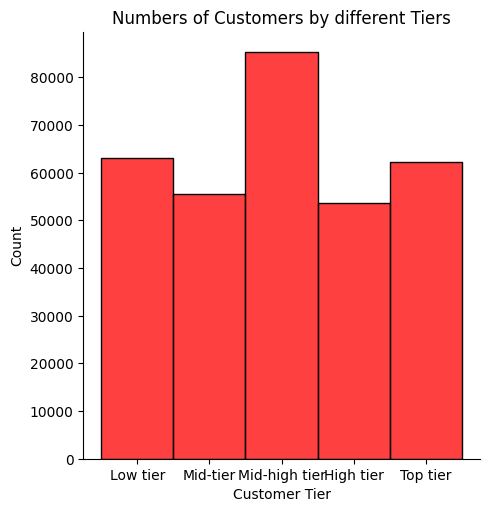

In [53]:
# Visualization
sns.displot(rfm['Tier'], color='red')
plt.title('Numbers of Customers by different Tiers')
plt.xlabel('Customer Tier')
plt.show()

## Value concentration analysis
Hypothesis: A small percentage of customers (the 'Champions'/high-RFM segment) generate a disproportionate share of total revenue.

In [55]:
rfm_value = rfm.groupby(['Tier']).monetary.sum()
rfm_value

/var/folders/1v/2zr5v4ln72s0cjq21hbhbv3w0000gn/T/ipykernel_2726/4057378783.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rfm_value = rfm.groupby(['Tier']).monetary.sum()


Tier
Low tier         3.660530e+05
Mid-tier         6.727643e+06
Mid-high tier    4.248222e+06
High tier        5.276835e+06
Top tier         1.147223e+07
Name: monetary, dtype: float64

In [56]:
rfm_value = rfm_value.to_frame()
type(rfm_value)

pandas.core.frame.DataFrame

In [57]:
def describe_value(rfm_value):
    # Total number of users
    total_users = len(rfm_value)

    # Total monetary value
    total_monetary = rfm_value["monetary"].sum()

    # User counts by tier
    top_high_users = rfm_value.loc[
        rfm_value["Tier"].isin(["Top tier", "High tier"])
    ].shape[0]

    mid_users = rfm_value.loc[
        rfm_value["Tier"].isin(["Mid-high tier", "Mid-tier"])
    ].shape[0]

    # User percentages
    top_high_user_pct = top_high_users / total_users * 100
    mid_user_pct = mid_users / total_users * 100

    # Monetary value by tier
    top_high_value = rfm_value.loc[
        rfm_value["Tier"].isin(["Top tier", "High tier"]),
        "monetary"
    ].sum()

    mid_value = rfm_value.loc[
        rfm_value["Tier"].isin(["Mid-high tier", "Mid-tier"]),
        "monetary"
    ].sum()

    # Monetary percentages
    top_high_value_pct = top_high_value / total_monetary * 100
    mid_value_pct = mid_value / total_monetary * 100

    # Output
    print(
        f"Value concentration: the top {top_high_user_pct:.2f}% of users "
        f"(Top + High tier) account for {top_high_value_pct:.2f}% "
        f"of total monetary value."
    )

    print(
        f"The remaining {mid_user_pct:.2f}% of users "
        f"(Mid-high + Mid tier) account for {mid_value_pct:.2f}% "
        f"of total monetary value."
    )


describe_value(rfm)

Value concentration: the top 36.19% of users (Top + High tier) account for 59.62% of total monetary value.
The remaining 44.05% of users (Mid-high + Mid tier) account for 39.07% of total monetary value.


## Recency analysis
Hypothesis: Customers whose Recency exceeds [X days] rarely return afterward. (Churn)

In [59]:
# merge Churn flags
rfm_churn = pd.merge(rfm, customer_summary, on='card_id', how='outer')
rfm_churn.head()

,card_id,recency,frequency,monetary,r,f,m,rfm,rfm points,Tier,first_purchase_date,last_purchase_date,total_orders,total_spend,days_since_last_purchase,churned_90d,AOV
0,C_ID_00007093c1,21 days,121,64.194000,3,4,5,345,12,High tier,2017-02-14 14:00:43,2018-02-08 16:37:19,121,64.194000,19,0,0.530529
1,C_ID_0001238066,2 days,113,44.172385,5,4,4,544,13,Top tier,2017-09-28 22:25:14,2018-02-27 16:18:59,113,44.172385,0,0,0.390906
2,C_ID_0001506ef0,12 days,66,31.398121,3,4,4,344,11,High tier,2017-01-14 16:16:01,2018-02-17 12:33:56,66,31.398121,10,0,0.475729
3,C_ID_0001793786,125 days,102,88.780546,1,4,5,145,10,Mid-high tier,2017-01-21 10:15:21,2017-10-27 13:51:16,102,88.780546,123,1,0.870398
4,C_ID_000183fdda,4 days,136,65.877791,4,5,5,455,14,Top tier,2017-08-07 09:49:14,2018-02-25 20:57:08,136,65.877791,2,0,0.484396


In [60]:
# convert recency to days
rfm_churn["recency_days"] = rfm_churn["recency"].dt.days

In [61]:
rfm_churn.groupby('Tier')[['r', 'f', 'm', 'rfm points', 'churned_90d']].mean()

/var/folders/1v/2zr5v4ln72s0cjq21hbhbv3w0000gn/T/ipykernel_2726/1200725728.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rfm_churn.groupby('Tier')[['r', 'f', 'm', 'rfm points', 'churned_90d']].mean()


,r,f,m,rfm points,churned_90d
Tier,,,,,
Low tier,1.676468,1.236541,1.237697,4.150706,0.493318
Mid-tier,2.515780,1.996885,2.008768,6.521433,0.229634
Mid-high tier,2.947949,3.017933,3.025861,8.991743,0.153679
High tier,3.373025,4.050032,4.042562,11.465618,0.090035
Top tier,4.527739,4.759244,4.743009,14.029992,0.000000


In [62]:
recency_counts = rfm_churn.groupby('Tier')[['r', 'recency']].mean()
# recency_counts = recency_counts.to_frame()
print(f'data type:', type(recency_counts))
recency_counts.head()

data type: <class 'pandas.core.frame.DataFrame'>


/var/folders/1v/2zr5v4ln72s0cjq21hbhbv3w0000gn/T/ipykernel_2726/315571147.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  recency_counts = rfm_churn.groupby('Tier')[['r', 'recency']].mean()


,r,recency
Tier,,
Low tier,1.676468,118 days 00:10:01.938058142
Mid-tier,2.515780,63 days 07:23:00.307858493
Mid-high tier,2.947949,44 days 22:53:10.185545729
High tier,3.373025,29 days 02:22:04.468681134
Top tier,4.527739,3 days 12:15:48.106194690


In [63]:
rfm_churn['Tier'].unique()

['High tier', 'Top tier', 'Mid-high tier', 'Mid-tier', 'Low tier']
Categories (5, object): ['Low tier' < 'Mid-tier' < 'Mid-high tier' < 'High tier' < 'Top tier']

In [64]:
rfm_top_tier = rfm_churn[rfm_churn['Tier'] == 'Top tier']
rfm_top_tier.head()

,card_id,recency,frequency,monetary,r,f,m,rfm,rfm points,Tier,first_purchase_date,last_purchase_date,total_orders,total_spend,days_since_last_purchase,churned_90d,AOV,recency_days
1,C_ID_0001238066,2 days,113,44.172385,5,4,4,544,13,Top tier,2017-09-28 22:25:14,2018-02-27 16:18:59,113,44.172385,0,0,0.390906,2
4,C_ID_000183fdda,4 days,136,65.877791,4,5,5,455,14,Top tier,2017-08-07 09:49:14,2018-02-25 20:57:08,136,65.877791,2,0,0.484396,4
15,C_ID_0003f41435,2 days,263,75.003837,5,5,5,555,15,Top tier,2017-06-14 11:28:58,2018-02-27 14:41:29,263,75.003837,0,0,0.285186,2
26,C_ID_0005f16cc8,1 days,146,55.843814,5,5,5,555,15,Top tier,2017-01-02 22:48:42,2018-02-28 16:05:17,146,55.843814,-1,0,0.382492,1
32,C_ID_0007fe3157,1 days,187,93.755851,5,5,5,555,15,Top tier,2017-05-02 18:33:11,2018-02-28 18:13:55,187,93.755851,-1,0,0.501368,1


In [65]:
# check the churn by tier
rfm_churn.groupby('Tier').churned_90d.mean()

/var/folders/1v/2zr5v4ln72s0cjq21hbhbv3w0000gn/T/ipykernel_2726/4181280862.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rfm_churn.groupby('Tier').churned_90d.mean()


Tier
Low tier         0.493318
Mid-tier         0.229634
Mid-high tier    0.153679
High tier        0.090035
Top tier         0.000000
Name: churned_90d, dtype: float64

In [66]:
# check the churn by recency score
rfm_churn.groupby('r').churned_90d.mean()

r
1    0.9672
2    0.0000
3    0.0000
4    0.0000
5    0.0000
Name: churned_90d, dtype: float64

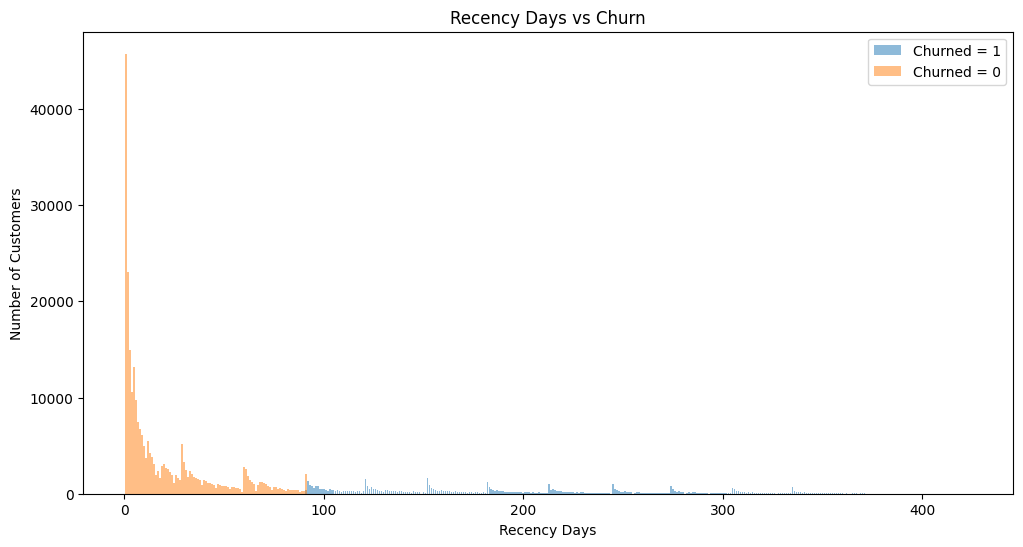

In [67]:
# Separate churned and non-churned customers
churned = rfm_churn[rfm_churn['churned_90d'] == 1]
not_churned = rfm_churn[rfm_churn['churned_90d'] == 0]

# Count customers at each recency value
churned_counts = churned['recency_days'].value_counts().sort_index()
not_churned_counts = not_churned['recency_days'].value_counts().sort_index()

# Plot
plt.figure(figsize=(12, 6))

plt.bar(
    churned_counts.index,
    churned_counts.values,
    alpha=0.5,
    label='Churned = 1'
)

plt.bar(
    not_churned_counts.index,
    not_churned_counts.values,
    alpha=0.5,
    label='Churned = 0'
)

plt.xlabel('Recency Days')
plt.ylabel('Number of Customers')
plt.title('Recency Days vs Churn')
plt.legend()

plt.show()

In [68]:
print(type(plt.xlabel))

<class 'function'>


## Frequency Analysis
Purchase frequency is a stronger predictor of total customer value (LTV) than average order size.
- LTV = use monetary value

In [70]:
rfm_churn.head()

,card_id,recency,frequency,monetary,r,f,m,rfm,rfm points,Tier,first_purchase_date,last_purchase_date,total_orders,total_spend,days_since_last_purchase,churned_90d,AOV,recency_days
0,C_ID_00007093c1,21 days,121,64.194000,3,4,5,345,12,High tier,2017-02-14 14:00:43,2018-02-08 16:37:19,121,64.194000,19,0,0.530529,21
1,C_ID_0001238066,2 days,113,44.172385,5,4,4,544,13,Top tier,2017-09-28 22:25:14,2018-02-27 16:18:59,113,44.172385,0,0,0.390906,2
2,C_ID_0001506ef0,12 days,66,31.398121,3,4,4,344,11,High tier,2017-01-14 16:16:01,2018-02-17 12:33:56,66,31.398121,10,0,0.475729,12
3,C_ID_0001793786,125 days,102,88.780546,1,4,5,145,10,Mid-high tier,2017-01-21 10:15:21,2017-10-27 13:51:16,102,88.780546,123,1,0.870398,125
4,C_ID_000183fdda,4 days,136,65.877791,4,5,5,455,14,Top tier,2017-08-07 09:49:14,2018-02-25 20:57:08,136,65.877791,2,0,0.484396,4


In [71]:
# group by tier
rfm_churn.groupby('Tier')[['f','frequency','monetary','AOV']].mean()

/var/folders/1v/2zr5v4ln72s0cjq21hbhbv3w0000gn/T/ipykernel_2726/2707802935.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rfm_churn.groupby('Tier')[['f','frequency','monetary','AOV']].mean()


,f,frequency,monetary,AOV
Tier,,,,
Low tier,1.236541,13.106451,5.796013,0.524238
Mid-tier,1.996885,27.561527,121.120586,9.638983
Mid-high tier,3.017933,53.965671,49.825499,1.435164
High tier,4.050032,114.616591,98.547690,1.157692
Top tier,4.759244,210.338858,184.589375,0.994924


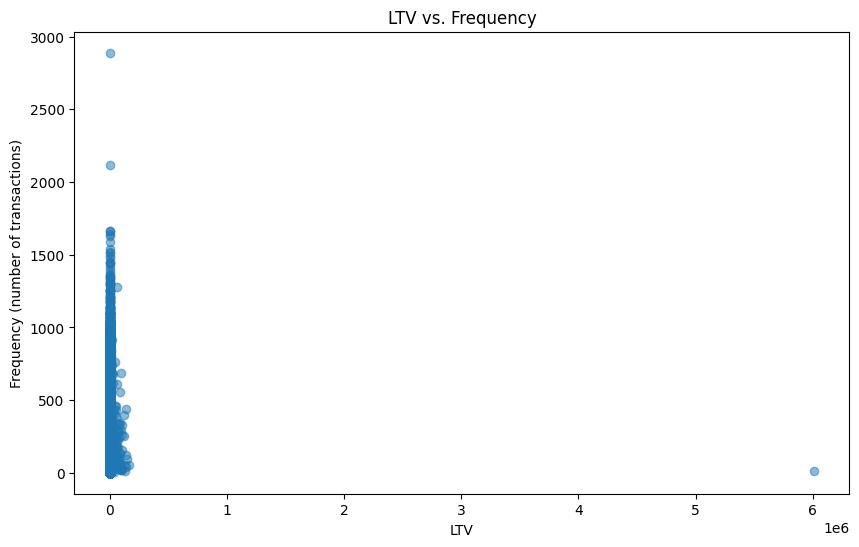

In [72]:
# plot frequency vs monetary (LTV) and AOV
def f_and_m_scatter_plot(df):
    # basic scatterplot
    plt.figure(figsize=(10, 6))

    plt.scatter(
        df['monetary'],
        df['frequency'],
        alpha=0.5
    )

    plt.xlabel('LTV')
    plt.ylabel('Frequency (number of transactions)')
    plt.title('LTV vs. Frequency')
    
    plt.show()

f_and_m_scatter_plot(rfm_churn)

In [73]:
# 1. Correlation analysis (Pearson + Spearman)
for var in ["frequency", "AOV", "recency_days"]:
    pearson_r, pearson_p = stats.pearsonr(rfm_churn[var], rfm_churn["monetary"])
    spearman_r, spearman_p = stats.spearmanr(rfm_churn[var], rfm_churn["monetary"])
    print(f"\n{var} vs monetary:")
    print(f"  Pearson  r = {pearson_r:.3f}  (p = {pearson_p:.5g})")
    print(f"  Spearman r = {spearman_r:.3f}  (p = {spearman_p:.5g})")


frequency vs monetary:
  Pearson  r = 0.006  (p = 0.0011769)
  Spearman r = 0.930  (p = 0)

AOV vs monetary:
  Pearson  r = 0.994  (p = 0)
  Spearman r = 0.083  (p = 0)

recency_days vs monetary:
  Pearson  r = 0.002  (p = 0.18427)
  Spearman r = -0.347  (p = 0)


In [74]:
for var in ["frequency", "recency_days", "monetary"]:
    pearson_r, pearson_p = stats.pearsonr(rfm_churn[var], rfm_churn["AOV"])
    spearman_r, spearman_p = stats.spearmanr(rfm_churn[var], rfm_churn["AOV"])
    print(f"\n{var} vs AOV:")
    print(f"  Pearson  r = {pearson_r:.3f}  (p = {pearson_p:.5g})")
    print(f"  Spearman r = {spearman_r:.3f}  (p = {spearman_p:.5g})")


frequency vs AOV:
  Pearson  r = -0.001  (p = 0.44556)
  Spearman r = -0.217  (p = 0)

recency_days vs AOV:
  Pearson  r = 0.004  (p = 0.034719)
  Spearman r = 0.036  (p = 1.2978e-93)

monetary vs AOV:
  Pearson  r = 0.994  (p = 0)
  Spearman r = 0.083  (p = 0)


In [75]:
# 2. Multiple regression with standardized coefficients
def multiple_regression(rfm):
    predictors = ["frequency", "AOV", "recency_days"]
    X = rfm[predictors].copy()
    y = rfm["monetary"].copy()

    # Standardize (z-score) so coefficients are comparable in magnitude
    X_std = (X - X.mean()) / X.std()
    y_std = (y - y.mean()) / y.std()
     
    X_std_const = sm.add_constant(X_std)
    model = sm.OLS(y_std, X_std_const).fit()
    print(model.summary())
     
    print("\nStandardized coefficients (beta weights):")
    print(model.params.drop("const").sort_values(key=abs, ascending=False))

In [76]:
# 2. Multiple regression with standardized coefficients

def multiple_regression(rfm, predictors, outcome):

    X = rfm[predictors].copy()
    y = rfm[outcome].copy()

    # Standardize (z-score) so coefficients are comparable in magnitude
    X_std = (X - X.mean()) / X.std()
    y_std = (y - y.mean()) / y.std()
     
    X_std_const = sm.add_constant(X_std)
    model = sm.OLS(y_std, X_std_const).fit()
    print(model.summary())
     
    print("\nStandardized coefficients (beta weights):")
    print(model.params.drop("const").sort_values(key=abs, ascending=False))

In [77]:
predictors = ["frequency", "AOV", "recency_days"]
outcome = "monetary"
multiple_regression(rfm_churn, predictors, outcome)

                            OLS Regression Results                            
Dep. Variable:               monetary   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                 8.981e+06
Date:                Fri, 28 Aug 2026   Prob (F-statistic):               0.00
Time:                        17:44:57   Log-Likelihood:             2.5703e+05
No. Observations:              319659   AIC:                        -5.140e+05
Df Residuals:                  319655   BIC:                        -5.140e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -6.967e-18      0.000  -3.64e-14   

In [78]:
predictors_aov = ["frequency", "monetary", "recency_days"]
outcome_aov = "AOV"
multiple_regression(rfm_churn, predictors_aov, outcome_aov)

                            OLS Regression Results                            
Dep. Variable:                    AOV   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                 8.980e+06
Date:                Fri, 28 Aug 2026   Prob (F-statistic):               0.00
Time:                        17:44:57   Log-Likelihood:             2.5702e+05
No. Observations:              319659   AIC:                        -5.140e+05
Df Residuals:                  319655   BIC:                        -5.140e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1.084e-17      0.000   5.66e-14   

### Frequency x Recency Analysis
Hypothesis: New/promising customers (low F, recent R) have a different average order value (AOV) than loyal customers (high F, high R).

In [80]:
# Descriptive analysis

In [81]:
# Hypothesis testing

### Revenue x Monetary Analysis

In [83]:
# save to csv
rfm_churn.to_csv("rfm_churn.csv", index=False)